# 📦 1. Toolkit Preparation


## Installing Libraries


In [ ]:
# %pip install "deps/fasttext-0.9.2-cp313-cp313-win_amd64.whl" matplotlib nltk numpy pandas regex scipy torch transformers wordcloud


References:

-   [1] A. Joulin, E. Grave, P. Bojanowski, T. Mikolov, Bag of Tricks for Efficient Text Classification
-   [2] A. Joulin, E. Grave, P. Bojanowski, M. Douze, H. Jégou, T. Mikolov, FastText.zip: Compressing text classification models


## Importing Libraries


In [14]:
from collections import defaultdict
from nltk import pos_tag
from nltk.corpus import wordnet as wn
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from scipy.special import softmax
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from wordcloud import WordCloud

import csv
import fasttext
import math
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import regex as re
import string
import unicodedata
import urllib.request

nltk.download("averaged_perceptron_tagger_eng")
nltk.download("vader_lexicon")
nltk.download("wordnet")


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# 📤 2. Data Loading


In [ ]:
def load_data(path, column):
    df = pd.read_csv(path, usecols=column)

    print("Total rows:", len(df))
    print(df.info())
    df.head()

    return df


In [16]:
raw_df = load_data("data/app_reviews_all.csv", ["content", "score"])
raw_ar_df = load_data("data/app_reviews_ar.csv", ["en_content", "score"])
raw_id_df = load_data("data/app_reviews_id.csv", ["en_content", "score"])
raw_vi_df = load_data("data/app_reviews_vi.csv", ["en_content", "score"])


Total rows: 53257
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53257 entries, 0 to 53256
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  53255 non-null  object
 1   score    53257 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 832.3+ KB
None
Total rows: 4349
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   score       4349 non-null   int64 
 1   en_content  4348 non-null   object
dtypes: int64(1), object(1)
memory usage: 68.1+ KB
None
Total rows: 6365
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6365 entries, 0 to 6364
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   score       6365 non-null   int64 
 1   en_content  6365 non-null   object
dtypes: int64(1), object(1)
memory usage: 99.6+

# 🫧 3. Text Preprocessing


## Preparation


### Contractions


In [ ]:
contraction_map = {
    "em": "them",
    "n": "and",
    "u": "you",
}

more_contraction_map = {
    "ain": "is not",
    "aincha": "is not you",
    "aint": "is not",
    "aintcha": "is not you",
    "aren": "are not",
    "arent": "are not",
    "cant": "cannot",
    "cmon": "come on",
    "comin": "coming",
    "coulda": "could have",
    "couldn": "could not",
    "couldnt": "could not",
    "didn": "did not",
    "didnt": "did not",
    "doin": "doing",
    "doesn": "does not",
    "doesnt": "does not",
    "don": "do not",
    "doncha": "do not you",
    "dont": "do not",
    "dunno": "do not know",
    "gimme": "give me",
    "givin": "giving",
    "goin": "going",
    "gonna": "going to",
    "gotcha": "got you",
    "gotta": "got to",
    "hadn": "had not",
    "hadnt": "had not",
    "hasn": "has not",
    "hasnt": "has not",
    "haven": "have not",
    "havent": "have not",
    "hed": "he would",
    "hedve": "he would have",
    "hellve": "he will have",
    "hes": "he is",
    "howd": "how did",
    "howdy": "how do you do",
    "howll": "how will",
    "hows": "how is",
    "idve": "i would have",
    "illve": "i will have",
    "im": "i am",
    "innit": "is it not",
    "ive": "i have",
    "isn": "is not",
    "isnt": "is not",
    "itd": "it would",
    "itdve": "it would have",
    "itll": "it will",
    "itllve": "it will have",
    "its": "it is",
    "kahnda": "kind of",
    "kinda": "kind of",
    "lets": "let us",
    "lemme": "let me",
    "lotta": "lot of",
    "mighta": "might have",
    "mightn": "might not",
    "mightnt": "might not",
    "musta": "must have",
    "mustn": "must not",
    "mustnt": "must not",
    "mustnta": "must not have",
    "needn": "need not",
    "neednt": "need not",
    "outta": "out of",
    "shan": "shall not",
    "shant": "shall not",
    "shed": "she would",
    "shedve": "she would have",
    "shell": "she will",
    "shellve": "she will have",
    "shes": "she is",
    "shoulda": "should have",
    "shouldn": "should not",
    "shouldnt": "should not",
    "shouldve": "should have",
    "sove": "so have",
    "sorta": "sort of",
    "thatd": "that would",
    "thatdve": "that would have",
    "thats": "that is",
    "thered": "there would",
    "theredve": "there would have",
    "theres": "there is",
    "theyd": "they would",
    "theydve": "they would have",
    "theyll": "they will",
    "theyllve": "they will have",
    "theyre": "they are",
    "theyve": "they have",
    "tove": "to have",
    "wasn": "was not",
    "wasnt": "was not",
    "wed": "we would",
    "wedve": "we would have",
    "wellve": "we will have",
    "weve": "we have",
    "weren": "were not",
    "werent": "were not",
    "whatll": "what will",
    "whatllve": "what will have",
    "whatre": "what are",
    "whats": "what is",
    "whatve": "what have",
    "whens": "when is",
    "whenve": "when have",
    "whered": "where did",
    "wheres": "where is",
    "whereve": "where have",
    "whod": "who would",
    "whodve": "who would have",
    "wholl": "who will",
    "whollve": "who will have",
    "whos": "who is",
    "whove": "who have",
    "whys": "why is",
    "whyve": "why have",
    "willve": "will have",
    "woncha": "will not you",
    "wont": "will not",
    "wontcha": "will not you",
    "woulda": "would have",
    "wanna": "want to",
    "wahta": "want to",
    "whatcha": "what are you",
    "wassup": "what is up",
    "yall": "you all",
    "yalld": "you all would",
    "yalldve": "you all would have",
    "yallre": "you all are",
    "yallve": "you all have",
    "youd": "you would",
    "youdve": "you would have",
    "youll": "you will",
    "youllve": "you will have",
    "youre": "you are",
    "youve": "you have",
}


### Punctuation & Symbols


In [ ]:
essential_punctuation = {
    ".",
    ",",
    "?",
    "!",
    ":",
    ";",
    "–",
    "—",
    "'",
    '"',
    "(",
    ")",
    "&",
}

essential_symbols = {
    "$",
    "€",
    "£",
    "¥",
    "+",
    "-",
    "*",
    "×",
    "/",
    "=",
    "~",
    "%",
    "^",
    "<",
    ">",
    "≤",
    "≥",
}


### Lemmatizer


In [ ]:
lemmatizer = WordNetLemmatizer()


def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wn.ADJ
    elif treebank_tag.startswith("V"):
        return wn.VERB
    elif treebank_tag.startswith("R"):
        return wn.ADV
    else:
        return wn.NOUN


## Preprocessing


In [ ]:
def preprocess(text):
    if not isinstance(text, str) or not text.strip():
        return text

    # Stripping accents/diacritics.
    text = unicodedata.normalize("NFKD", text)
    text = "".join([c for c in text if not unicodedata.combining(c)])

    # Collapse repeated 3+ alphabet characters.
    text = re.sub(r"([a-zA-Z])\1{2,}", r"\1", text)

    # Remove punctuation and symbols, but keep only the essentials.
    text = "".join(
        char
        for char in text
        if char not in string.punctuation
        or char in essential_punctuation
        or char in essential_symbols
    )

    # Add one space before each emoji (if not already preceded by a space).
    text = re.sub(r"(?<! )(\p{Extended_Pictographic})", r" \1", text)

    # Expand contractions.
    text = " ".join(contraction_map.get(word, word) for word in text.split())

    # Collapse excessive whitespace (include tabs and newlines).
    text = re.sub(r"\s+", " ", text).strip()

    # Finish.
    return text


def normalize_punctuation(text):
    # Collapse repeated punctuation and symbols into a single character.
    text = re.sub(r"([\p{P}\p{S}])\1+", r"\1", text)

    # Remove spaces before punctuation [.,!?].
    text = re.sub(r"\s+([.,!?])", r"\1", text)

    # Ensure exactly one space after punctuation [.,!?] (unless end of string).
    text = re.sub(r"([.,!?])(?!\s|$)", r"\1 ", text)

    return text


def minimal_preprocess(text):
    if not isinstance(text, str) or not text.strip():
        return text

    # Casefolding.
    text = text.lower()

    # Normalize punctuation.
    text = normalize_punctuation(text)

    # Remove punctuation (while avoiding some contractions collapsing into similar-sounding words) and symbols, except [.,!?"&+-/=%<>] and currency + preserving emojis.
    text = re.sub(r"\bhe'll\b", "he will", text)
    text = re.sub(r"\bi'd\b", "i would", text)
    text = re.sub(r"\bi'll\b", "i will", text)
    text = re.sub(r"\bso's\b", "so is", text)
    text = re.sub(r"\bwe'll\b", "we will", text)
    text = re.sub(r"\bwe're\b", "we are", text)

    text = re.sub(
        r"\bai's\b",
        "ai",
        text,  # Fix: WordNet was mistagged "ais" as JJ instead of a noun.
    )

    text = re.sub(r"'", "", text)

    text = re.sub(
        r"[^\p{L}\p{N}\p{Zs}\p{Sc}.,!?\"&+\-\/=%<>\p{Extended_Pictographic}]",
        " ",  # Replace it with whitespace.
        text,
    )

    # Collapse excessive whitespace (include tabs and newlines).
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization.
    tokens = text.split()

    # More contraction expansion.
    tokens_expanded = []
    for word in tokens:
        expanded = more_contraction_map.get(word, word)
        tokens_expanded.extend(expanded.split())

    # Lemmatization.
    tagged_tokens = pos_tag(tokens_expanded)
    lemmatized_tokens = [
        (
            lemmatizer.lemmatize(token, get_wordnet_pos(tag))
            if token != "as"  # Prevent "as" collapsing into "a".
            else token
        )
        for token, tag in tagged_tokens
    ]

    return " ".join(lemmatized_tokens)


In [ ]:
def preprocess_data(df, content_column="content"):
    df["clean_content"] = df[content_column].apply(preprocess)
    df["minimal_content"] = df["clean_content"].apply(minimal_preprocess)

    print(df[[content_column, "clean_content", "minimal_content"]].head())

    return df


In [22]:
clean_df = preprocess_data(raw_df)


                                             content  \
0  Not accurate! I love the idea of this app as i...   
1  Please be aware that the app quietly increased...   
2  Mixed feelings. As a person who's close to a C...   
3  If anyone wants to see a bunch of in-app purch...   
4  Frustrating and depressing. "Please increase t...   

                                       clean_content  \
0  Not accurate! I love the idea of this app as i...   
1  Please be aware that the app quietly increased...   
2  Mixed feelings. As a person who's close to a C...   
3  If anyone wants to see a bunch of in-app purch...   
4  Frustrating and depressing. "Please increase t...   

                                     minimal_content  
0  not accurate! i love the idea of this app as i...  
1  please be aware that the app quietly increase ...  
2  mixed feelings. as a person who be close to a ...  
3  if anyone want to see a bunch of in-app purcha...  
4  frustrating and depressing. "please increase t..

In [23]:
clean_ar_df = preprocess_data(raw_ar_df, "en_content")


                                          en_content  \
0  Very good, I hope that some training in conver...   
1  The program is its form and sweet, I have not ...   
2  The best application to learn English, pronunc...   
3  A bad and very heavy program on the mobile and...   
4  Why the screen suddenly closes and why he is w...   

                                       clean_content  \
0  Very good, I hope that some training in conver...   
1  The program is its form and sweet, I have not ...   
2  The best application to learn English, pronunc...   
3  A bad and very heavy program on the mobile and...   
4  Why the screen suddenly closes and why he is w...   

                                     minimal_content  
0  very good, i hope that some training in conver...  
1  the program be it be form and sweet, i have no...  
2  the best application to learn english, pronunc...  
3  a bad and very heavy program on the mobile and...  
4  why the screen suddenly close and why he be we..

In [24]:
clean_id_df = preprocess_data(raw_id_df, "en_content")


                                          en_content  \
0  The voice recognition please fix it. It is cor...   
1  If you only ask me to subscribe to this APK, p...   
2  I just downloaded this application because it ...   
3  I paid the Elsa Pro 1 year package on the 7th ...   
4  a little disappointed, every time I play why y...   

                                       clean_content  \
0  The voice recognition please fix it. It is cor...   
1  If you only ask me to subscribe to this APK, p...   
2  I just downloaded this application because it ...   
3  I paid the Elsa Pro 1 year package on the 7th ...   
4  a little disappointed, every time I play why y...   

                                     minimal_content  
0  the voice recognition please fix it. it be cor...  
1  if you only ask me to subscribe to this apk, p...  
2  i just download this application because it be...  
3  i pay the elsa pro 1 year package on the 7th t...  
4  a little disappointed, every time i play why y..

In [25]:
clean_vi_df = preprocess_data(raw_vi_df, "en_content")


                                          en_content  \
0  The strange design interface, after finishing,...   
1  Whoever is deaf using the app at the same time...   
2  The app does not respond continuously extremel...   
3  Oh, oh, really the app is very good, can point...   
4  Too bad. Many improvements are not equal to th...   

                                       clean_content  \
0  The strange design interface, after finishing,...   
1  Whoever is deaf using the app at the same time...   
2  The app does not respond continuously extremel...   
3  Oh, oh, really the app is very good, can point...   
4  Too bad. Many improvements are not equal to th...   

                                     minimal_content  
0  the strange design interface, after finishing,...  
1  whoever be deaf use the app at the same time t...  
2  the app do not respond continuously extremely ...  
3  oh, oh, really the app be very good, can point...  
4  too bad. many improvement be not equal to the ..

## Handling Blanks & Duplicates


In [ ]:
final_clean_df = clean_df.copy()
final_clean_ar_df = clean_ar_df.copy()
final_clean_id_df = clean_id_df.copy()
final_clean_vi_df = clean_vi_df.copy()


### Remove Blanks


In [27]:
# Identify if there are any empty rows and duplicates after preprocessing.
def check_blanks(clean_df, content_column="content"):
    blank_rows = clean_df[clean_df["minimal_content"].fillna("").str.strip() == ""]
    print(
        f"Empty content rows ({len(blank_rows)}/{len(clean_df)}):\n{blank_rows[[content_column]].to_string()}"
    )


def remove_blanks(clean_df):
    return clean_df[clean_df["minimal_content"].fillna("").str.strip() != ""]


check_blanks(clean_df)
check_blanks(clean_ar_df, content_column="en_content")
check_blanks(clean_id_df, content_column="en_content")
check_blanks(clean_vi_df, content_column="en_content")


Empty content rows (8/53257):
        content
38635        ုံ
41617       NaN
44027     ☆☆☆☆☆
49015       NaN
49168        ;)
52590        :)
52775  :) (: ;)
53248     ☆☆☆☆☆
Empty content rows (1/4349):
     en_content
4278        NaN
Empty content rows (1/6365):
     en_content
5189         🇲🇨
Empty content rows (1/27062):
      en_content
23759      ☆☆☆☆☆


In [28]:
final_clean_df = remove_blanks(final_clean_df)
final_clean_ar_df = remove_blanks(final_clean_ar_df)
final_clean_id_df = remove_blanks(final_clean_id_df)
final_clean_vi_df = remove_blanks(final_clean_vi_df)

print("Remaining rows (EN):", len(final_clean_df))
print("Remaining rows (AR):", len(final_clean_ar_df))
print("Remaining rows (ID):", len(final_clean_id_df))
print("Remaining rows (VI):", len(final_clean_vi_df), "\n")

check_blanks(final_clean_df)
check_blanks(final_clean_ar_df, content_column="en_content")
check_blanks(final_clean_id_df, content_column="en_content")
check_blanks(final_clean_vi_df, content_column="en_content")


Remaining rows (EN): 53249
Remaining rows (AR): 4348
Remaining rows (ID): 6364
Remaining rows (VI): 27061 

Empty content rows (0/53249):
Empty DataFrame
Columns: [content]
Index: []
Empty content rows (0/4348):
Empty DataFrame
Columns: [en_content]
Index: []
Empty content rows (0/6364):
Empty DataFrame
Columns: [en_content]
Index: []
Empty content rows (0/27061):
Empty DataFrame
Columns: [en_content]
Index: []


### Remove Duplicates


In [29]:
def check_cross_duplicates():
    combined_df = pd.concat(
        [
            final_clean_df.assign(source="en"),
            final_clean_ar_df.assign(source="ar"),
            final_clean_id_df.assign(source="id"),
            final_clean_vi_df.assign(source="vi"),
        ],
        ignore_index=True,
    )

    duplicate_rows = combined_df[combined_df.duplicated(subset=["minimal_content"])]

    print(
        f"Duplicate rows ({len(duplicate_rows)}/{len(combined_df)}):\n{duplicate_rows[["minimal_content"]]}"
    )


def remove_cross_duplicates():
    combined_df = pd.concat(
        [
            final_clean_df.assign(source="en"),
            final_clean_ar_df.assign(source="ar"),
            final_clean_id_df.assign(source="id"),
            final_clean_vi_df.assign(source="vi"),
        ],
        ignore_index=True,
    )

    # Identify duplicates and keep the first occurrence.
    combined_df = combined_df.drop_duplicates(subset=["minimal_content"], keep="first")

    result_en = (
        combined_df[combined_df["source"] == "en"]
        .drop(columns=["source", "en_content"])
        .reset_index()
    )
    result_ar = (
        combined_df[combined_df["source"] == "ar"]
        .drop(columns=["source"])
        .reset_index()
    )
    result_id = (
        combined_df[combined_df["source"] == "id"]
        .drop(columns=["source"])
        .reset_index()
    )
    result_vi = (
        combined_df[combined_df["source"] == "vi"]
        .drop(columns=["source"])
        .reset_index()
    )

    return {
        "final_clean_df": result_en,
        "final_clean_ar_df": result_ar,
        "final_clean_id_df": result_id,
        "final_clean_vi_df": result_vi,
    }


check_cross_duplicates()


Duplicate rows (42369/91022):
                                         minimal_content
1206   really it be good specially for pronunciation....
5174                very good to practice pronunciation.
5323                    very good app for learn english.
5916                                       very good app
6039                    very good app for learn english.
...                                                  ...
91013                                                ok.
91016                                             great.
91017                                                ❤ ❤
91019                                                  ❤
91021                                                  👎

[42369 rows x 1 columns]


In [31]:
result = remove_cross_duplicates()

final_clean_df = result["final_clean_df"]
final_clean_ar_df = result["final_clean_ar_df"]
final_clean_id_df = result["final_clean_id_df"]
final_clean_vi_df = result["final_clean_vi_df"]

print("Remaining rows (EN):", len(final_clean_df))
print("Remaining rows (AR):", len(final_clean_ar_df))
print("Remaining rows (ID):", len(final_clean_id_df))
print("Remaining rows (VI):", len(final_clean_vi_df), "\n")

check_cross_duplicates()


Remaining rows (EN): 30533
Remaining rows (AR): 2115
Remaining rows (ID): 3290
Remaining rows (VI): 12715 

Duplicate rows (0/48653):
Empty DataFrame
Columns: [minimal_content]
Index: []


## Language Filtering


In [ ]:
# Detect reviews' language using fastText.
MODEL = fasttext.load_model("deps/lid.176.bin")


def detect_language(text):
    label, prob = MODEL.predict(text)
    lang = label[0].replace("__label__", "")  # type: ignore
    return {"language": lang, "probability": prob[0]}


def add_language_detection(final_clean_df):
    language_df = (
        final_clean_df["minimal_content"].apply(detect_language).apply(pd.Series)
    )
    final_clean_df[["lang", "lang_prob"]] = language_df[["language", "probability"]]

    print(final_clean_df[["minimal_content", "lang", "lang_prob"]].head())

    return final_clean_df


In [36]:
final_clean_df = add_language_detection(final_clean_df)


                                     minimal_content lang  lang_prob
0  not accurate! i love the idea of this app as i...   en   0.954228
1  please be aware that the app quietly increase ...   en   0.928180
2  mixed feelings. as a person who be close to a ...   en   0.950711
3  if anyone want to see a bunch of in-app purcha...   en   0.959278
4  frustrating and depressing. "please increase t...   en   0.956088


In [33]:
final_clean_ar_df = add_language_detection(final_clean_ar_df)


                                     minimal_content lang  lang_prob
0  very good, i hope that some training in conver...   en   0.950142
1  the program be it be form and sweet, i have no...   en   0.927311
2  the best application to learn english, pronunc...   en   0.931673
3  a bad and very heavy program on the mobile and...   en   0.892199
4  why the screen suddenly close and why he be we...   en   0.950431


In [37]:
final_clean_id_df = add_language_detection(final_clean_id_df)


                                     minimal_content lang  lang_prob
0  the voice recognition please fix it. it be cor...   en   0.935513
1  if you only ask me to subscribe to this apk, p...   en   0.942860
2  i just download this application because it be...   en   0.965278
3  i pay the elsa pro 1 year package on the 7th t...   en   0.969538
4  a little disappointed, every time i play why y...   en   0.949949


In [38]:
final_clean_vi_df = add_language_detection(final_clean_vi_df)


                                     minimal_content lang  lang_prob
0  the strange design interface, after finishing,...   en   0.948415
1  whoever be deaf use the app at the same time t...   en   0.812251
2  the app do not respond continuously extremely ...   en   0.932625
3  oh, oh, really the app be very good, can point...   en   0.968336
4  too bad. many improvement be not equal to the ...   en   0.923642


In [ ]:
def filter_english_entries(df):
    english_mask = (df["lang"] == "en") & (df["lang_prob"] >= 0.5)
    english_df = df[english_mask]

    print(f"Total in English: {len(english_df)}/{len(df)}")

    df = df[english_mask]

    print("Remaining rows:", len(df))

    return df


In [39]:
final_clean_df = filter_english_entries(final_clean_df)


Total in English: 26111/30533
Remaining rows: 26111


In [35]:
final_clean_ar_df = filter_english_entries(final_clean_ar_df)


Total in English: 1826/2115
Remaining rows: 1826


In [40]:
final_clean_id_df = filter_english_entries(final_clean_id_df)


Total in English: 2972/3290
Remaining rows: 2972


In [41]:
final_clean_vi_df = filter_english_entries(final_clean_vi_df)


Total in English: 11752/12715
Remaining rows: 11752


## Take Top Relevant


In [ ]:
# top_60_percent_rows = clean_df.iloc[: int(len(clean_df) * 0.6)]

# print("Total top 60%:", len(top_60_percent_rows))


In [ ]:
# clean_df = top_60_percent_rows.copy()

# print("Remaining rows:", len(clean_df))


## Storing Cleaned


In [ ]:
final_clean_df.to_csv("data/app_reviews_all_cleaned.csv", index=False)
final_clean_ar_df.to_csv("data/app_reviews_ar_cleaned.csv", index=False)
final_clean_id_df.to_csv("data/app_reviews_id_cleaned.csv", index=False)
final_clean_vi_df.to_csv("data/app_reviews_vi_cleaned.csv", index=False)


# 🏷️ 4. Data Labeling


## Data Loading


In [ ]:
def load_data(path):
    df = pd.read_csv(path)
    print(df.head())
    return df


In [44]:
df = load_data("data/app_reviews_all_cleaned.csv")
df_ar = load_data("data/app_reviews_ar_cleaned.csv")
df_id = load_data("data/app_reviews_id_cleaned.csv")
df_vi = load_data("data/app_reviews_vi_cleaned.csv")


   level_0  index                                            content  score  \
0        0      0  Not accurate! I love the idea of this app as i...      2   
1        1      1  Please be aware that the app quietly increased...      1   
2        2      2  Mixed feelings. As a person who's close to a C...      3   
3        3      3  If anyone wants to see a bunch of in-app purch...      1   
4        4      4  Frustrating and depressing. "Please increase t...      2   

                                       clean_content  \
0  Not accurate! I love the idea of this app as i...   
1  Please be aware that the app quietly increased...   
2  Mixed feelings. As a person who's close to a C...   
3  If anyone wants to see a bunch of in-app purch...   
4  Frustrating and depressing. "Please increase t...   

                                     minimal_content lang  lang_prob  
0  not accurate! i love the idea of this app as i...   en   0.954228  
1  please be aware that the app quietly increa

## Star Sentiment


In [ ]:
def stars_to_sentiment(score: int):
    if score <= 2:
        return "negative"
    elif score <= 4:
        return "neutral"
    else:
        return "positive"


def add_star_sentiments(df):
    df["star_sentiment"] = df["score"].apply(stars_to_sentiment)
    print(df["star_sentiment"].value_counts().sort_index())
    return df


In [46]:
df = add_star_sentiments(df)
df_ar = add_star_sentiments(df_ar)
df_id = add_star_sentiments(df_id)
df_vi = add_star_sentiments(df_vi)

# Star sentiments are frequently inconsistent.


star_sentiment
negative     3193
neutral      4479
positive    18439
Name: count, dtype: int64
star_sentiment
negative     273
neutral      274
positive    1279
Name: count, dtype: int64
star_sentiment
negative     202
neutral      390
positive    2380
Name: count, dtype: int64
star_sentiment
negative    1705
neutral     1541
positive    8506
Name: count, dtype: int64


## VADER Sentiment


In [ ]:
sia = SentimentIntensityAnalyzer()


def vader_predict(text):
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.3:
        return "positive", score
    elif score <= -0.15:
        return "negative", score
    else:
        return "neutral", score


def add_vader_sentiments(df):
    vader_results = df["minimal_content"].apply(vader_predict)
    df["vader_sentiment"] = [r[0] for r in vader_results]
    df["vader_score"] = [r[1] for r in vader_results]

    print(df["vader_sentiment"].value_counts().sort_index())

    return df


In [48]:
df = add_vader_sentiments(df)
df_ar = add_vader_sentiments(df_ar)
df_id = add_vader_sentiments(df_id)
df_vi = add_vader_sentiments(df_vi)


vader_sentiment
negative     1633
neutral      3488
positive    20990
Name: count, dtype: int64
vader_sentiment
negative     184
neutral      400
positive    1242
Name: count, dtype: int64
vader_sentiment
negative     132
neutral      464
positive    2376
Name: count, dtype: int64
vader_sentiment
negative    1327
neutral     2704
positive    7721
Name: count, dtype: int64


## RoBERTa Sentiment


In [123]:
# Load model and tokenizer.
task = "sentiment"
MODEL = f"cardiffnlp/twitter-roberta-base-{task}-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

# Download label mapping (label id to name).
mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{task}/mapping.txt"
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode("utf-8").split("\n")
    csvreader = csv.reader(html, delimiter="\t")
    labels = [row[1] for row in csvreader if len(row) > 1]

# Threshold values.
POSITIVE_THRESHOLD = 0.65
NEGATIVE_THRESHOLD = 0.45


def label_prediction(probabilities):
    # ranking = np.argmax(probabilities)
    # return labels[ranking], probabilities[ranking]

    # Create label to index mapping for safe access.
    label_idx = {label: idx for idx, label in enumerate(labels)}

    # Get scores for each sentiment.
    negative_confidence = probabilities[label_idx["negative"]]
    neutral_confidence = probabilities[label_idx["neutral"]]
    positive_confidence = probabilities[label_idx["positive"]]

    # Determine final prediction with threshold logic.
    # Strategy: Check thresholds, then pick highest probability among qualifying classes.

    # Check which classes meet their thresholds.
    positive_qualifies = positive_confidence >= POSITIVE_THRESHOLD
    negative_qualifies = negative_confidence >= NEGATIVE_THRESHOLD
    # Neutral has no threshold, always qualifies.

    # Decision logic.
    if positive_qualifies and negative_qualifies:
        # Both meet threshold, pick the higher confidence.
        if positive_confidence > negative_confidence:
            predicted_label = "positive"
            confidence = positive_confidence
        else:
            predicted_label = "negative"
            confidence = negative_confidence
    elif positive_qualifies:
        # Only positive meets threshold.
        predicted_label = "positive"
        confidence = positive_confidence
    elif negative_qualifies:
        # Only negative meets threshold.
        predicted_label = "negative"
        confidence = negative_confidence
    else:
        # Neither meets threshold, default to neutral.
        predicted_label = "neutral"
        confidence = neutral_confidence

    return predicted_label, confidence


def roberta_predict(text, star_rating):
    # Get base RoBERTa predictions.
    encoded_input = tokenizer(
        text, return_tensors="pt", truncation=True, max_length=512
    )
    output = model(**encoded_input)

    scores = output.logits[0].detach().numpy()
    probabilities = softmax(scores)

    # Get final prediction with threshold logic.
    result = label_prediction(probabilities)

    return {
        "label": result[0],
        "confidence": result[1],
        "scores": dict(zip(labels, probabilities)),
        "star_rating": star_rating,
    }


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
def add_roberta_sentiment(df):
    roberta_results = df.apply(
        lambda row: roberta_predict(row["minimal_content"], row["score"]), axis=1
    )

    df["roberta_sentiment"] = [r["label"] for r in roberta_results]
    df["roberta_confidence"] = [r["confidence"] for r in roberta_results]
    df["roberta_conf_neg"] = [r["scores"]["negative"] for r in roberta_results]
    df["roberta_conf_neu"] = [r["scores"]["neutral"] for r in roberta_results]
    df["roberta_conf_pos"] = [r["scores"]["positive"] for r in roberta_results]

    print(df["roberta_sentiment"].value_counts().sort_index())

    return df


In [ ]:
df = add_roberta_sentiment(df)


roberta_sentiment
negative     2513
neutral      3923
positive    19675
Name: count, dtype: int64


In [51]:
df_ar = add_roberta_sentiment(df_ar)


roberta_sentiment
negative     182
neutral      486
positive    1158
Name: count, dtype: int64


In [ ]:
df_id = add_roberta_sentiment(df_id)


roberta_sentiment
negative     173
neutral      648
positive    2154
Name: count, dtype: int64


In [ ]:
df_vi = add_roberta_sentiment(df_vi)


roberta_sentiment
negative    1450
neutral     3572
positive    6745
Name: count, dtype: int64


## RoBERTa Relabeling (if needed)


In [ ]:
def relabel_roberta(data_path):
    df = pd.read_csv(data_path)

    roberta_results = df.apply(
        lambda row: label_prediction(
            probabilities=[
                row["roberta_conf_neg"],
                row["roberta_conf_neu"],
                row["roberta_conf_pos"],
            ]
        ),
        axis=1,
    )

    df["roberta_sentiment"] = [r[0] for r in roberta_results]
    df["roberta_confidence"] = [r[1] for r in roberta_results]

    print(df["roberta_sentiment"].value_counts().sort_index())

    return df


In [125]:
df = relabel_roberta("data/app_reviews_all_labeled.csv")
df_ar = relabel_roberta("data/app_reviews_ar_labeled.csv")
df_id = relabel_roberta("data/app_reviews_id_labeled.csv")
df_vi = relabel_roberta("data/app_reviews_vi_labeled.csv")


roberta_sentiment
negative     2991
neutral      3557
positive    19563
Name: count, dtype: int64
roberta_sentiment
negative     208
neutral      460
positive    1158
Name: count, dtype: int64
roberta_sentiment
negative     222
neutral      622
positive    2131
Name: count, dtype: int64
roberta_sentiment
negative    1900
neutral     3186
positive    6681
Name: count, dtype: int64


## Storing Labeled


In [ ]:
df.to_csv("data/app_reviews_all_labeled.csv", index=False)
df_ar.to_csv("data/app_reviews_ar_labeled.csv", index=False)
df_id.to_csv("data/app_reviews_id_labeled.csv", index=False)
df_vi.to_csv("data/app_reviews_vi_labeled.csv", index=False)


# 🔎 5. Exploratory Data Analysis


## Sentiment Check


In [136]:
def check_sentiment(df):
    print(
        df[
            [
                "score",
                "minimal_content",
                "star_sentiment",
                "vader_sentiment",
                "roberta_sentiment",
                "vader_score",
                "roberta_confidence",
            ]
        ].head()
    )


def check_roberta(df):
    print(
        df[
            [
                "score",
                "minimal_content",
                "roberta_sentiment",
                "roberta_confidence",
                "roberta_conf_neg",
                "roberta_conf_neu",
                "roberta_conf_pos",
            ]
        ].head()
    )


In [137]:
check_sentiment(df)
check_sentiment(df_ar)
check_sentiment(df_id)
check_sentiment(df_vi)

# Conclusion: ✅ RoBERTa is way more accurate than star and VADER sentiment.


   score                                    minimal_content star_sentiment  \
0      2  not accurate! i love the idea of this app as i...       negative   
1      1  please be aware that the app quietly increase ...       negative   
2      3  mixed feelings. as a person who be close to a ...        neutral   
3      1  if anyone want to see a bunch of in-app purcha...       negative   
4      2  frustrating and depressing. "please increase t...       negative   

  vader_sentiment roberta_sentiment  vader_score  roberta_confidence  
0        negative           neutral      -0.2097            0.274532  
1        positive           neutral       0.7345            0.848505  
2        positive           neutral       0.7506            0.488917  
3        positive          negative       0.3415            0.918350  
4         neutral          negative       0.0267            0.892307  
   score                                    minimal_content star_sentiment  \
0      3  very good, i hope

In [138]:
check_roberta(df)
check_roberta(df_ar)
check_roberta(df_id)
check_roberta(df_vi)


   score                                    minimal_content roberta_sentiment  \
0      2  not accurate! i love the idea of this app as i...           neutral   
1      1  please be aware that the app quietly increase ...           neutral   
2      3  mixed feelings. as a person who be close to a ...           neutral   
3      1  if anyone want to see a bunch of in-app purcha...          negative   
4      2  frustrating and depressing. "please increase t...          negative   

   roberta_confidence  roberta_conf_neg  roberta_conf_neu  roberta_conf_pos  
0            0.274532          0.432934          0.274532          0.292534  
1            0.848505          0.086114          0.848505          0.065382  
2            0.488917          0.443455          0.488917          0.067628  
3            0.918350          0.918350          0.067761          0.013889  
4            0.892307          0.892307          0.097990          0.009703  
   score                                    m

# 🧫 6. Data Sampling


## Data Loading


In [128]:
df = load_data("data/app_reviews_all_labeled.csv")
df_ar = load_data("data/app_reviews_ar_labeled.csv")
df_id = load_data("data/app_reviews_id_labeled.csv")
df_vi = load_data("data/app_reviews_vi_labeled.csv")


   index                                            content  score  \
0      0  Not accurate! I love the idea of this app as i...      2   
1      1  Please be aware that the app quietly increased...      1   
2      2  Mixed feelings. As a person who's close to a C...      3   
3      3  If anyone wants to see a bunch of in-app purch...      1   
4      4  Frustrating and depressing. "Please increase t...      2   

                                       clean_content  \
0  Not accurate! I love the idea of this app as i...   
1  Please be aware that the app quietly increased...   
2  Mixed feelings. As a person who's close to a C...   
3  If anyone wants to see a bunch of in-app purch...   
4  Frustrating and depressing. "Please increase t...   

                                     minimal_content lang  lang_prob  \
0  not accurate! i love the idea of this app as i...   en   0.954228   
1  please be aware that the app quietly increase ...   en   0.928180   
2  mixed feelings. as a pe

## Class Balance Check


In [139]:
def check_class_balance(df):
    print(df["roberta_sentiment"].value_counts().sort_index())


check_class_balance(df)
check_class_balance(df_ar)
check_class_balance(df_id)
check_class_balance(df_vi)


roberta_sentiment
negative     2991
neutral      3557
positive    19563
Name: count, dtype: int64
roberta_sentiment
negative     208
neutral      460
positive    1158
Name: count, dtype: int64
roberta_sentiment
negative     222
neutral      622
positive    2131
Name: count, dtype: int64
roberta_sentiment
negative    1900
neutral     3186
positive    6681
Name: count, dtype: int64


## Stratified Sampling


In [ ]:
def balanced_sample(
    dfs, n_total=10000, label_col="roberta_sentiment", random_state=42, verbose=True
):
    """
    Balanced sampler.

    Strategy:
      - Compute global availability per class.
      - Use an iterative "water-filling" (capacity capping) to compute integer
        targets per class that respect both n_total and class availability.
      - For each class, distribute its target across dataframes proportionally
        to that class's availability in each dataframe (rounded fairly).
      - Sample per-dataframe/per-class accordingly (no duplicates; deterministic RNG).
      - Verbose logging shows global avail, per-class targets, per-DF draws, final totals.

    Returns:
      combined_df, negative_df, neutral_df, positive_df
    """

    # Tag copies so we do not mutate user dataframes.
    dfs_tagged = [
        df.copy().assign(_source_id=i, _orig_index=df.index) for i, df in enumerate(dfs)
    ]
    n_dfs = len(dfs_tagged)

    # Gather class set.
    classes = sorted(set().union(*[set(df[label_col].unique()) for df in dfs_tagged]))

    # Compute availability per-df and global totals.
    avail_per_df = {i: defaultdict(int) for i in range(n_dfs)}
    total_avail = defaultdict(int)
    for i, df in enumerate(dfs_tagged):
        vc = df[label_col].value_counts()
        for cls, cnt in vc.items():
            avail_per_df[i][cls] = int(cnt)
            total_avail[cls] += int(cnt)

    total_available_all = sum(total_avail.values())

    # WATER-FILLING / CAPACITY CAPPING.
    remaining_total = min(n_total, total_available_all)
    remaining_classes = set(classes)
    allocation = {}
    while remaining_classes:
        k = len(remaining_classes)
        target = remaining_total / k
        # Classes that cannot reach the current per-class target (cap them).
        small = [cls for cls in list(remaining_classes) if total_avail[cls] <= target]
        if not small:
            # Everyone can satisfy the evenly split target; assign integer split.
            base = remaining_total // k
            rem = int(remaining_total % k)
            sorted_classes = sorted(remaining_classes)
            for j, cls in enumerate(sorted_classes):
                allocation[cls] = int(base + (1 if j < rem else 0))
            break
        else:
            # Cap those small classes at their availability and repeat.
            for cls in sorted(small):
                allocation[cls] = int(total_avail[cls])
                remaining_total -= allocation[cls]
                remaining_classes.remove(cls)

    # Distribute each class target across dataframes proportionally (with fair rounding).
    per_df_alloc = {i: {cls: 0 for cls in classes} for i in range(n_dfs)}
    for cls, target in allocation.items():
        total_cls_avail = total_avail[cls]
        # desired fractional allocation per df.
        desired = []
        for i in range(n_dfs):
            avail = avail_per_df[i].get(cls, 0)
            dfloat = (avail / total_cls_avail * target) if total_cls_avail > 0 else 0
            desired.append((i, avail, dfloat))

        # floor allocation from fractional target.
        alloc = {i: min(avail, int(math.floor(dfloat))) for i, avail, dfloat in desired}
        allocated = sum(alloc.values())
        rem = int(target - allocated)

        # Distribute the remaining 1s by fractional remainder, respecting per-df avail limits.
        remainders = sorted(
            [(i, dfloat - math.floor(dfloat), avail) for i, avail, dfloat in desired],
            key=lambda x: x[1],
            reverse=True,
        )
        for i, frac, avail in remainders:
            if rem <= 0:
                break
            if alloc[i] < avail:
                alloc[i] += 1
                rem -= 1

        # If still remainder, give to any df with spare capacity (largest spare first).
        if rem > 0:
            caps = sorted(
                [(i, avail - alloc[i]) for i, avail, dfloat in desired],
                key=lambda x: x[1],
                reverse=True,
            )
            for i, cap in caps:
                while cap > 0 and rem > 0:
                    alloc[i] += 1
                    rem -= 1
                    cap -= 1
                if rem == 0:
                    break

        for i in range(n_dfs):
            per_df_alloc[i][cls] = alloc.get(i, 0)

    # Sample according to per_df_alloc.
    sampled_parts = []
    class_drawn_per_df = defaultdict(int)
    for i, df in enumerate(dfs_tagged):
        picks = []
        for cls in classes:
            take = per_df_alloc[i].get(cls, 0)
            class_drawn_per_df[(i + 1, cls)] = take
            if take > 0:
                picks.append(
                    df[df[label_col] == cls].sample(n=take, random_state=random_state)
                )
        if picks:
            sampled_parts.append(pd.concat(picks))

    if sampled_parts:
        combined_df = pd.concat(sampled_parts, ignore_index=True)
    else:
        # no data matched (edge-case).
        combined_df = pd.DataFrame(columns=dfs_tagged[0].columns)

    # Final shuffle + splits.
    combined_df = combined_df.sample(frac=1, random_state=random_state).reset_index(
        drop=True
    )
    negative_df = combined_df[combined_df[label_col] == "negative"]
    neutral_df = combined_df[combined_df[label_col] == "neutral"]
    positive_df = combined_df[combined_df[label_col] == "positive"]

    # Verbose, transparent logging.
    if verbose:
        print("\n===== ⚙️ Balanced Sample Report ⚙️ =====")
        print(f"Requested total: {n_total:,}")
        print(f"Final total:     {len(combined_df):,}")
        print("\n📦 Global availability per class:")
        for cls in classes:
            print(f"  {cls:<8}: {total_avail.get(cls,0):,}")
        print("\n🎯 Target allocation per class (water-filling):")
        for cls in classes:
            print(f"  {cls:<8}: {allocation.get(cls,0):,}")
        print("\n📊 Per-DataFrame allocations (rows drawn):")
        for (i, cls), cnt in sorted(class_drawn_per_df.items()):
            print(f"  DF{i:<2} {cls:<8}: {cnt:,}")
        print("\n✅ Final per-class totals:")
        for cls in classes:
            print(f"  {cls:<8}: {combined_df[label_col].value_counts().get(cls,0):,}")
        if total_available_all < n_total:
            print(
                "\n⚠️  Warning: total available data < requested total; returning maximum possible."
            )
        print("===================================\n")

    # Clean helper columns if present.
    for col in ["_source_id", "_orig_index"]:
        if col in combined_df.columns:
            combined_df = combined_df.drop(columns=col)
            negative_df = negative_df.drop(columns=col, errors="ignore")
            neutral_df = neutral_df.drop(columns=col, errors="ignore")
            positive_df = positive_df.drop(columns=col, errors="ignore")

    return combined_df, negative_df, neutral_df, positive_df


In [130]:
final_df, negative_df, neutral_df, positive_df = balanced_sample(
    [df, df_ar, df_id, df_vi], n_total=15963
)

print("Negative:", negative_df[["minimal_content"]].head())
print("\nNeutral:", neutral_df[["minimal_content"]].head())
print("\nPositive:", positive_df[["minimal_content"]].head())



===== ⚙️ Balanced Sample Report ⚙️ =====
Requested total: 15,963
Final total:     15,963

📦 Global availability per class:
  negative: 5,321
  neutral : 7,825
  positive: 29,533

🎯 Target allocation per class (water-filling):
  negative: 5,321
  neutral : 5,321
  positive: 5,321

📊 Per-DataFrame allocations (rows drawn):
  DF1  negative: 2,991
  DF1  neutral : 2,419
  DF1  positive: 3,525
  DF2  negative: 208
  DF2  neutral : 313
  DF2  positive: 208
  DF3  negative: 222
  DF3  neutral : 423
  DF3  positive: 384
  DF4  negative: 1,900
  DF4  neutral : 2,166
  DF4  positive: 1,204

✅ Final per-class totals:
  negative: 5,321
  neutral : 5,321
  positive: 5,321

Negative:                                      minimal_content
0  i have a continuous problem! do not recognize ...
3  i do not like the application because there be...
5  it be a very bad app. the personalized plan do...
6           also but very expensive money my account
7  plis initially this app be really good, alread...

N

In [131]:
# Only take the relevant columns.
relevant_columns = ["score", "clean_content", "minimal_content", "roberta_sentiment"]
final_df = final_df[relevant_columns]

print("Total rows:", len(final_df))
final_df.head()


Total rows: 15963


,score,clean_content,minimal_content,roberta_sentiment
0,1,I have a continuous problem! Do not recognize ...,i have a continuous problem! do not recognize ...,negative
1,3,Read new to eat,read new to eat,neutral
2,5,Learn very good pronunciation. Identify errors...,learn very good pronunciation. identify error ...,positive
3,1,I did not like the application because there i...,i do not like the application because there be...,negative
4,5,Make it easier to study English,make it easy to study english,neutral


## Class Balance Recheck


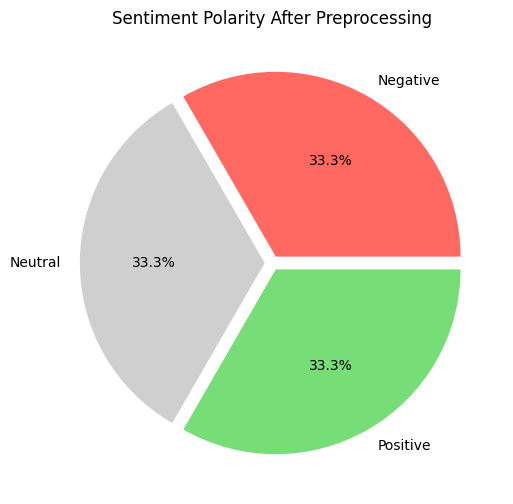

In [132]:
# Class balance check after sampling.
def plot_polarity(polarity, title):
    polarity.plot(
        autopct="%1.1f%%",
        colors=["#ff6961", "#cfcfcf", "#77dd77"],
        explode=[0.04] * 3,
        figsize=(6, 6),
        kind="pie",
        labels=["Negative", "Neutral", "Positive"],
        title=title,
        ylabel="",
    )


plot_polarity(
    final_df["roberta_sentiment"].value_counts().sort_index(),
    title="Sentiment Polarity After Preprocessing",
)


## Word Clouds


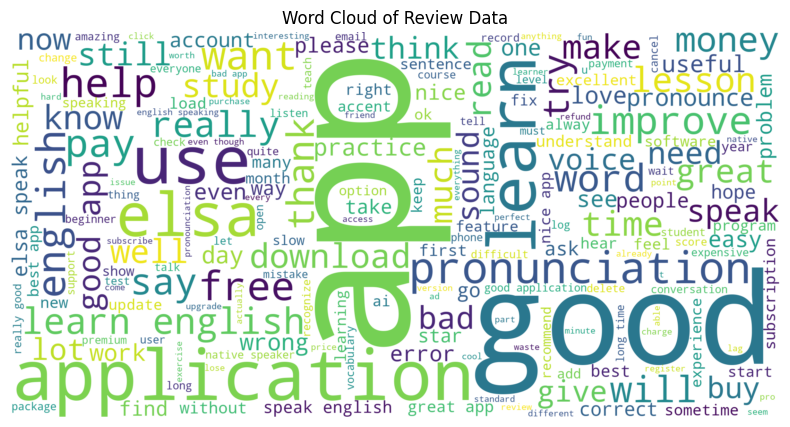

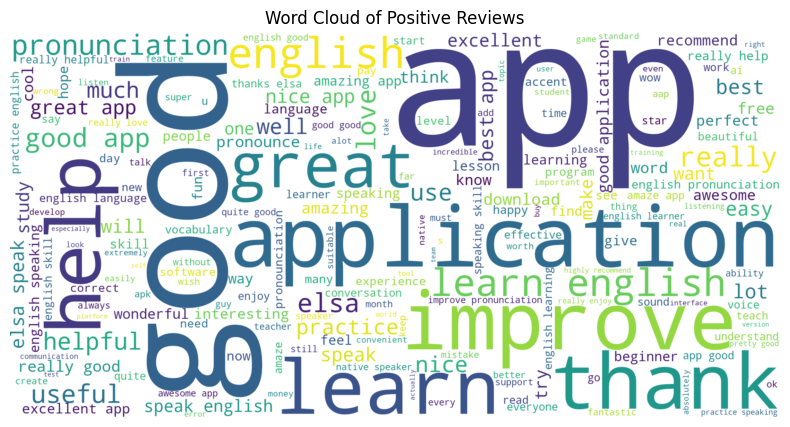

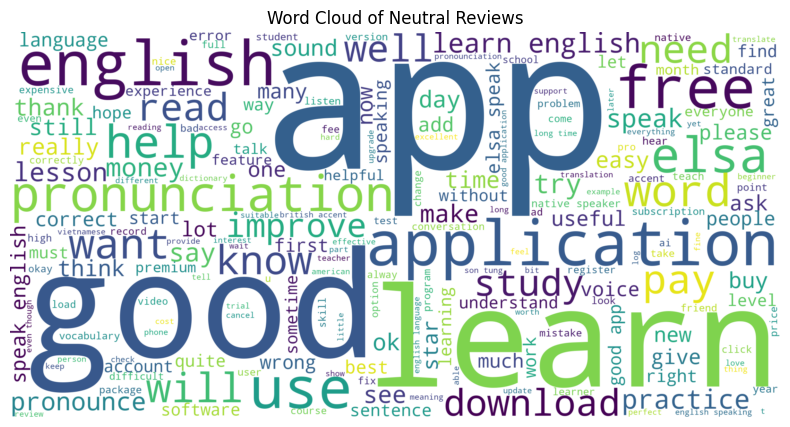

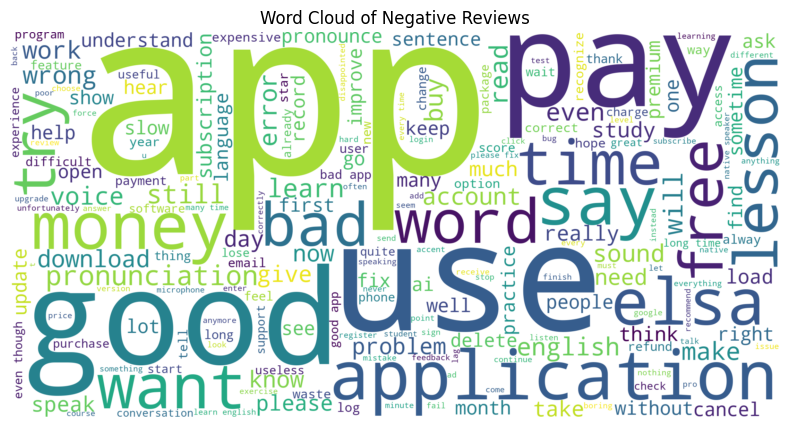

In [141]:
# Show word clouds to reveal which tokens dominate the text corpus after preprocessing and sampling.
def merge_texts(texts):
    return " ".join(text for text in texts)


general_text = merge_texts(final_df["minimal_content"])
positive_text = merge_texts(positive_df["minimal_content"])
neutral_text = merge_texts(neutral_df["minimal_content"])
negative_text = merge_texts(negative_df["minimal_content"])


def plot_wordcloud(text, title):
    wordcloud = WordCloud(
        background_color="white",
        height=1200,
        margin=0,
        max_words=200,
        width=2400,
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.savefig(f"history/{title.lower().replace(" ", "_")}.png")
    plt.show()


plot_wordcloud(general_text, "Word Cloud of Review Data")
plot_wordcloud(positive_text, "Word Cloud of Positive Reviews")
plot_wordcloud(neutral_text, "Word Cloud of Neutral Reviews")
plot_wordcloud(negative_text, "Word Cloud of Negative Reviews")


# 🫙 7. Storing Results


In [ ]:
final_df.to_csv("data/app_reviews_ready.csv", index=False)
